# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

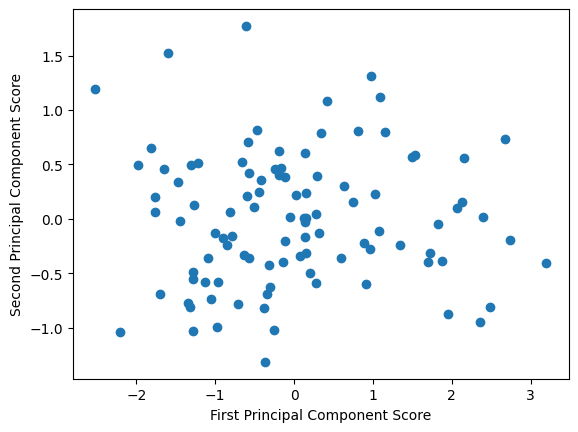

In [7]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper left have low PC1 scores and high PC2 scores, meaning they have low values in series_3 but high values in both series_1 and series_2. It is easier to interpret series_3 because it has more variability and dominates the first principal component, while series_1 and series_2 are highly correlated and behave almost like the same variable, making them difficult to distinguish in the PCA plot.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [8]:
import pandas as pd

file_path = "EdStatsData.csv (3).zip"
df = pd.read_csv("EdStatsData.csv (2).zip")

selected_indicators = [
    "Adjusted net enrolment rate, lower secondary, both sexes (%)",
    "Adjusted net enrolment rate, lower secondary, female (%)",
    "Adjusted net enrolment rate, lower secondary, male (%)",
    "Adjusted net enrolment rate, primary, both sexes (%)",
    "Adjusted net enrolment rate, primary, female (%)",
    "Adjusted net enrolment rate, primary, male (%)"
]

years = [str(year) for year in range(2000, 2015)]

us_df = df[
    (df["Country Name"] == "United States") &
    (df["Indicator Name"].isin(selected_indicators))
]

edu_data = us_df.set_index("Indicator Name")[years].T
edu_data = edu_data.apply(pd.to_numeric, errors="coerce")

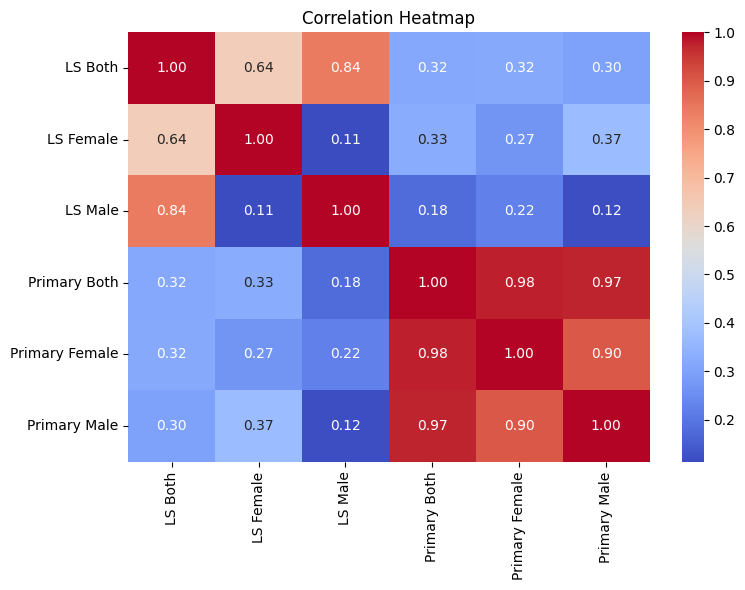

In [9]:
import seaborn as sns 

short_names = [
    "LS Both",
    "LS Female",
    "LS Male",
    "Primary Both",
    "Primary Female",
    "Primary Male"
]

corr = edu_data.corr()
corr.columns = short_names
corr.index = short_names

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap shows strong positive correlations between most of the enrollment variables. This is expected because male, female, and total enrollment rates are closely related and tend to move together. The primary and secondary enrollment variables are also positively correlated, suggesting that countries with strong primary enrollment tend to also have strong secondary enrollment.


Explained Variance Ratio:
[0.56826377 0.27353436]


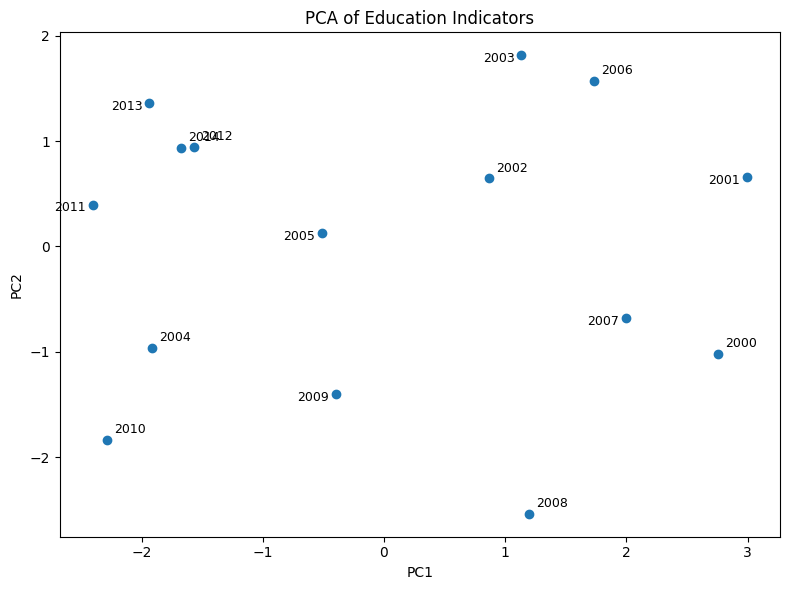

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(edu_data)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"])

for i, year in enumerate(edu_data.index):
    offset = (5,5) if i % 2 == 0 else (-5,-5)
    
    plt.annotate(
        year,
        (pca_df.iloc[i, 0], pca_df.iloc[i, 1]),
        textcoords="offset points",
        xytext=offset,
        ha='left' if i % 2 == 0 else 'right',
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Education Indicators")
plt.tight_layout()
plt.show()

(On the top left corner, it 2012 overlaps with 2014 for reference). The PCA results show that the first principal component captures most of the variance in the dataset. This suggests that many of the variables are moving together and can be summarized using a single dominant direction. The second principal component captures a smaller portion of the variation and reflects more subtle differences between the indicators. Overall, this indicates that the dataset can be reduced to fewer dimensions without losing much information.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np

target = "Adjusted net enrolment rate, lower secondary, both sexes (%)"

features = [
    "Adjusted net enrolment rate, lower secondary, female (%)",
    "Adjusted net enrolment rate, lower secondary, male (%)",
    "Adjusted net enrolment rate, primary, both sexes (%)"
]

X = edu_data[features]
y = edu_data[target]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

print("R^2:", r2)
print("RMSE:", rmse)

R^2: 0.999987278616493
RMSE: 0.0029849619412355734


The linear regression model performed really well, with an r2 value almost equal to 1 and a very low RMSE. This shows that the features I used explain nearly all of the variation in the target variable. This makes sense since variables like male and female enrollment rates are very similar to the total enrollment rate. Overall, the model is very accurate, but that is mostly because the variables are highly correlated and closely related to each other.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

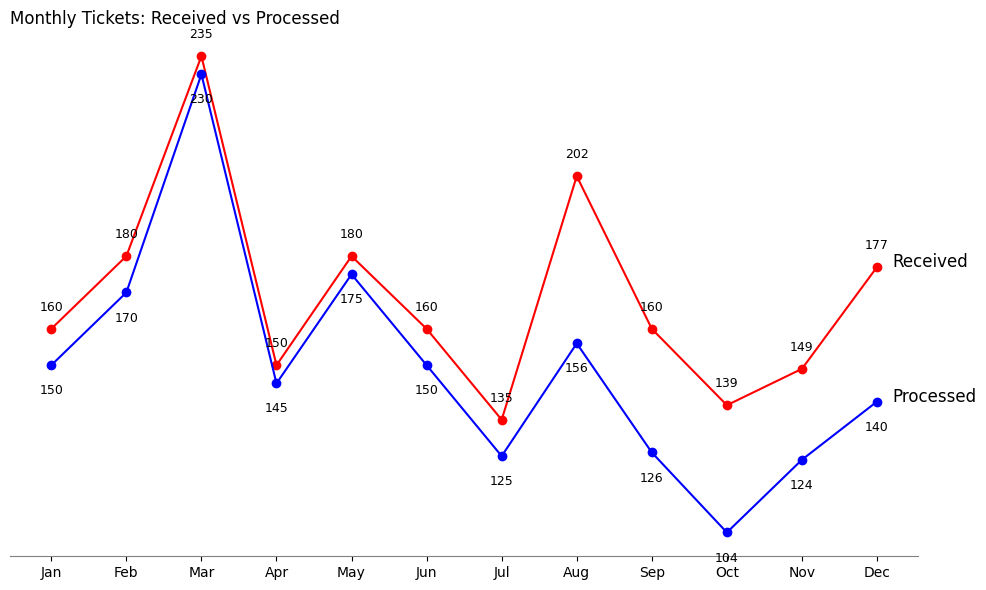

In [12]:
# Months
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = np.arange(len(months))

# Approximate data (just for look & feel)
received = [160, 180, 235, 150, 180, 160, 135, 202, 160, 139, 149, 177]
processed = [150, 170, 230, 145, 175, 150, 125, 156, 126, 104, 124, 140]

plt.figure(figsize=(10,6))

# Plot lines
plt.plot(x, received, color="red", marker='o')
plt.plot(x, processed, color="blue", marker='o')


plt.xticks(x, months)
plt.yticks([])  
plt.grid(False)


for spine in ["top","right","left"]:
    plt.gca().spines[spine].set_visible(False)

plt.gca().spines["bottom"].set_color("gray")


for i in range(len(x)):
    plt.text(x[i], received[i]+5, str(received[i]), ha='center', fontsize=9)
    plt.text(x[i], processed[i]-8, str(processed[i]), ha='center', fontsize=9)

plt.text(11.2, received[-1], "Received", fontsize=12)
plt.text(11.2, processed[-1], "Processed", fontsize=12)

plt.title("Monthly Tickets: Received vs Processed", loc='left')

plt.tight_layout()
plt.show()